In [1]:
import os, sys, platform; print(f"{platform.python_implementation()} {platform.python_version()} | {platform.system()} {platform.release()} | CPU: {platform.processor() or platform.machine()} | logical CPUs: {os.cpu_count()}")

CPython 3.12.13 | Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | logical CPUs: 24


In [2]:
from pathlib import Path

INPUT_PATH = Path(r"..\sample\PT\00013 Torso PET AC OSEM")
# INPUT_PATH = Path(r"..\sample\nema\Multiframe\CT\DISCIMG\IMAGES\CT0001")
INPUT_PATH


WindowsPath('../sample/PT/00013 Torso PET AC OSEM')

# Basic 3D VTK loading and geometry comparison

Use this notebook to compare how `vtk`, `vtkgdcm`, and `dicomsdl.vtk_bridge`
load a 3D volume.

`INPUT_PATH` can point to either:

- a DICOM series directory
- a single multiframe DICOM file

The goal here is not timing, but quick geometry and array-layout checks.


In [3]:
import sys
from pathlib import Path

import numpy as np


def _find_repo_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "bindings" / "python" / "dicomsdl").is_dir():
        return cwd
    if cwd.name == "tutorials" and (cwd.parent / "bindings" / "python" / "dicomsdl").is_dir():
        return cwd.parent
    return cwd


def _series_file_names(series_dir: Path) -> list[str]:
    file_names = [
        str(child)
        for child in sorted(series_dir.iterdir())
        if child.is_file() and child.suffix.lower() == ".dcm"
    ]
    if not file_names:
        raise RuntimeError(f"No .dcm files found under {series_dir}")
    return file_names


def _vtk_string_array():
    try:
        from vtkmodules.vtkCommonCore import vtkStringArray
    except ImportError:
        import vtk  # type: ignore
        return vtk.vtkStringArray
    return vtkStringArray


def _vtk_array_from_image(image):
    try:
        from vtkmodules.util.numpy_support import vtk_to_numpy
    except ImportError:
        from vtk.util.numpy_support import vtk_to_numpy  # type: ignore

    scalars = image.GetPointData().GetScalars()
    if scalars is None:
        raise RuntimeError("Reader did not produce scalar data")

    dims = tuple(int(v) for v in image.GetDimensions())
    components = int(scalars.GetNumberOfComponents())
    flat = vtk_to_numpy(scalars)
    if components == 1:
        array = flat.reshape(dims[2], dims[1], dims[0])
    else:
        array = flat.reshape(dims[2], dims[1], dims[0], components)
    return np.array(array, copy=True)


def _vtk_direction_tuple(image):
    matrix = image.GetDirectionMatrix()
    return tuple(
        float(matrix.GetElement(row, col))
        for row in range(3)
        for col in range(3)
    )


def _print_vtk_summary(label, image):
    array = _vtk_array_from_image(image)
    print(label)
    print("  dims:", tuple(int(v) for v in image.GetDimensions()))
    print("  spacing:", tuple(float(v) for v in image.GetSpacing()))
    print("  origin:", tuple(float(v) for v in image.GetOrigin()))
    print("  direction:", _vtk_direction_tuple(image))
    print("  shape:", tuple(int(v) for v in array.shape))
    print("  dtype:", array.dtype)
    print("  range:", (array.min(), array.max()))
    return array


def _compare_arrays(label_a, array_a, label_b, array_b):
    print(f"{label_a} shape:", array_a.shape)
    print(f"{label_b} shape:", array_b.shape)
    same_shape = array_a.shape == array_b.shape
    print("same shape:", same_shape)
    if not same_shape:
        return
    print("direct equal:", np.array_equal(array_a, array_b))
    if array_a.ndim >= 3:
        print("flip_y equal:", np.array_equal(array_a[:, ::-1, ...], array_b))
        print("flip_zy equal:", np.array_equal(array_a[::-1, ::-1, ...], array_b))


def _image_position_orientation_derived_display_spacing(input_path: Path, image) -> tuple[float, float, float] | None:
    import dicomsdl as dicom

    if not input_path.is_dir():
        return None

    file_names = _series_file_names(input_path)
    if len(file_names) < 2:
        return None

    series_entries = []
    for file_name in file_names:
        dicom_file = dicom.read_file(file_name, load_until=dicom.Tag("0020,0037"))
        if not hasattr(dicom_file, "ImagePositionPatient") or not hasattr(dicom_file, "ImageOrientationPatient"):
            return None
        origin = np.asarray([float(value) for value in dicom_file.ImagePositionPatient], dtype=np.float64)
        orientation = [float(value) for value in dicom_file.ImageOrientationPatient]
        row = np.asarray(orientation[:3], dtype=np.float64)
        col = np.asarray(orientation[3:], dtype=np.float64)
        row /= np.linalg.norm(row)
        col /= np.linalg.norm(col)
        normal = np.cross(row, col)
        normal /= np.linalg.norm(normal)
        series_entries.append((origin, normal))

    base_origin, base_normal = series_entries[0]
    projected = sorted(
        float(np.dot(origin - base_origin, base_normal))
        for origin, _normal in series_entries
    )
    positive_diffs = [
        projected[index + 1] - projected[index]
        for index in range(len(projected) - 1)
        if projected[index + 1] - projected[index] > 1e-6
    ]
    if not positive_diffs:
        return None

    spacing = tuple(float(v) for v in image.GetSpacing())
    derived_z = float(np.median(np.asarray(positive_diffs, dtype=np.float64)))
    return (abs(spacing[0]), abs(spacing[1]), abs(derived_z))


def _show_center_orthogonal_slices(image, array, label, spacing_override=None):
    import matplotlib.pyplot as plt

    if array.ndim != 3:
        raise RuntimeError(f"Expected a 3D scalar volume, got shape {array.shape}")

    image_spacing = tuple(float(v) for v in image.GetSpacing())
    spacing = spacing_override or image_spacing
    spacing = tuple(abs(float(v)) for v in spacing)
    center_z = array.shape[0] // 2
    center_y = array.shape[1] // 2
    center_x = array.shape[2] // 2

    axial_slice = array[center_z, :, :]
    coronal_slice = array[:, center_y, :]
    sagittal_slice = array[:, :, center_x]

    panels = [
        (
            "Axial",
            axial_slice,
            (0.0, axial_slice.shape[1] * spacing[0], axial_slice.shape[0] * spacing[1], 0.0),
            "X distance (mm)",
            "Y distance (mm)",
            f"z={center_z}",
        ),
        (
            "Coronal",
            coronal_slice,
            (0.0, coronal_slice.shape[1] * spacing[0], coronal_slice.shape[0] * spacing[2], 0.0),
            "X distance (mm)",
            "Slice axis distance (mm)",
            f"y={center_y}",
        ),
        (
            "Sagittal",
            sagittal_slice,
            (0.0, sagittal_slice.shape[1] * spacing[1], sagittal_slice.shape[0] * spacing[2], 0.0),
            "Y distance (mm)",
            "Slice axis distance (mm)",
            f"x={center_x}",
        ),
    ]

    print(f"{label} image spacing: {image_spacing}")
    if spacing_override is not None:
        print(f"{label} display spacing override: {spacing}")
    print(f"{label} center indices: z={center_z}, y={center_y}, x={center_x}")
    for plane_name, plane_slice, extent, _, _, plane_index in panels:
        width_mm = extent[1] - extent[0]
        height_mm = extent[2] - extent[3]
        print(
            f"{label} {plane_name.lower()} {plane_index}: "
            f"shape={plane_slice.shape}, display={width_mm:.3f} x {height_mm:.3f} mm"
        )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
    last_image = None
    for axis, (plane_name, plane_slice, extent, xlabel, ylabel, plane_index) in zip(axes, panels):
        last_image = axis.imshow(
            plane_slice,
            cmap="gray",
            extent=extent,
            aspect="equal",
            interpolation="nearest",
        )
        axis.set_title(f"{plane_name} ({plane_index})")
        axis.set_xlabel(xlabel)
        axis.set_ylabel(ylabel)

    fig.suptitle(f"{label} center orthogonal slices")
    if last_image is not None:
        fig.colorbar(last_image, ax=axes, shrink=0.9)
    plt.show()


def _read_with_vtk(input_path: Path):
    import vtk  # type: ignore

    reader = vtk.vtkDICOMImageReader()
    if input_path.is_dir():
        reader.SetDirectoryName(str(input_path))
    else:
        reader.SetFileName(str(input_path))
    reader.Update()
    return reader.GetOutput()


def _read_with_vtkgdcm(input_path: Path):
    from vtkgdcm import vtkGDCMImageReader  # type: ignore

    reader = vtkGDCMImageReader()
    if input_path.is_dir():
        vtk_string_array = _vtk_string_array()
        file_names = vtk_string_array()
        for file_name in _series_file_names(input_path):
            file_names.InsertNextValue(file_name)
        reader.SetFileNames(file_names)
    else:
        reader.SetFileName(str(input_path))
    reader.Update()
    return reader.GetOutput()


def _read_with_dicomsdl(input_path: Path):
    from dicomsdl.vtk_bridge import read_series_image_data

    return read_series_image_data(
        input_path,
        to_modality_value=True,
        copy=False,
    )


REPO_ROOT = _find_repo_root()
repo_python_dir = REPO_ROOT / "bindings" / "python"
if repo_python_dir.is_dir():
    repo_python_text = str(repo_python_dir)
    if repo_python_text not in sys.path:
        sys.path.insert(0, repo_python_text)

INPUT_PATH = Path(INPUT_PATH)
if not INPUT_PATH.is_absolute():
    INPUT_PATH = (REPO_ROOT / INPUT_PATH).resolve()
if not INPUT_PATH.exists():
    raise FileNotFoundError(INPUT_PATH)

print(f"Repo root: {REPO_ROOT}")
print(f"Input path: {INPUT_PATH}")
print(f"Input kind: {'directory series' if INPUT_PATH.is_dir() else 'single file'}")


Repo root: C:\Lab\workspace\test.git
Input path: C:\Lab\workspace\sample\PT\00013 Torso PET AC OSEM
Input kind: directory series


## `vtk.vtkDICOMImageReader`

This is the stock VTK DICOM reader.


In [4]:
vtk_image = _read_with_vtk(INPUT_PATH)
vtk_array = _print_vtk_summary("vtk.vtkDICOMImageReader", vtk_image)

vtk.vtkDICOMImageReader
  dims: (192, 192, 341)
  spacing: (2.6041667461395264, 2.6041667461395264, 2.7899999618530273)
  origin: (0.0, 0.0, 0.0)
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
  shape: (341, 192, 192)
  dtype: float32
  range: (np.float32(0.0), np.float32(54127.48))


## `vtkgdcm.vtkGDCMImageReader`

This is the VTK reader backed by GDCM.


In [5]:
vtkgdcm_image = _read_with_vtkgdcm(INPUT_PATH)
vtkgdcm_array = _print_vtk_summary("vtkgdcm.vtkGDCMImageReader", vtkgdcm_image)

vtkgdcm.vtkGDCMImageReader
  dims: (192, 192, 341)
  spacing: (2.6041667461395, 2.6041667461395, 1.0)
  origin: (-248.698, 248.69784851264453, 10.0)
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
  shape: (341, 192, 192)
  dtype: float64
  range: (np.float64(0.0), np.float64(54127.47963))


## Center orthogonal slices from `vtkgdcm` (raw)

This first view uses the `vtkImageData` spacing reported directly by
`vtkgdcm.vtkGDCMImageReader`.


vtkgdcm raw image spacing: (2.6041667461395, 2.6041667461395, 1.0)
vtkgdcm raw center indices: z=170, y=96, x=96
vtkgdcm raw axial z=170: shape=(192, 192), display=500.000 x 500.000 mm
vtkgdcm raw coronal y=96: shape=(341, 192), display=500.000 x 341.000 mm
vtkgdcm raw sagittal x=96: shape=(341, 192), display=500.000 x 341.000 mm


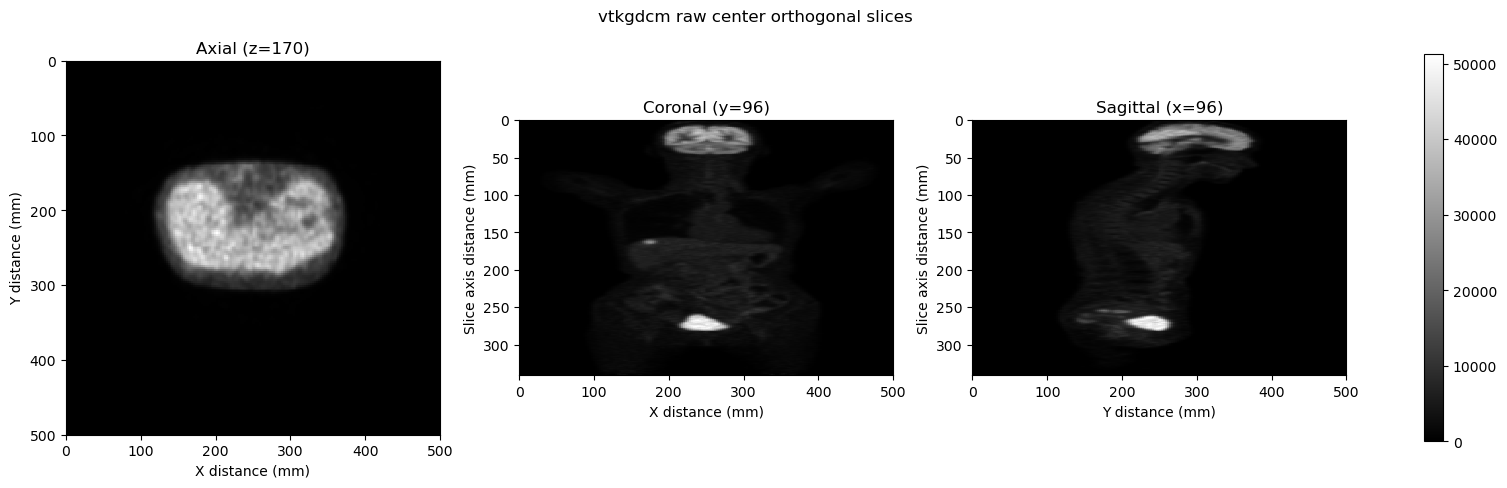

In [6]:
vtkgdcm_volume_image = vtkgdcm_image
vtkgdcm_volume_array = vtkgdcm_array

_show_center_orthogonal_slices(
    vtkgdcm_volume_image,
    vtkgdcm_volume_array,
    "vtkgdcm raw",
)


## Center orthogonal slices from `vtkgdcm` with image-position-derived z spacing

For file-per-slice series, this view keeps the `vtkgdcm` voxel array layout but
replaces the displayed z spacing with a value derived from image position and
image orientation metadata.


vtkgdcm corrected image spacing: (2.6041667461395, 2.6041667461395, 1.0)
vtkgdcm corrected display spacing override: (2.6041667461395, 2.6041667461395, 2.789999999999992)
vtkgdcm corrected center indices: z=170, y=96, x=96
vtkgdcm corrected axial z=170: shape=(192, 192), display=500.000 x 500.000 mm
vtkgdcm corrected coronal y=96: shape=(341, 192), display=500.000 x 951.390 mm
vtkgdcm corrected sagittal x=96: shape=(341, 192), display=500.000 x 951.390 mm


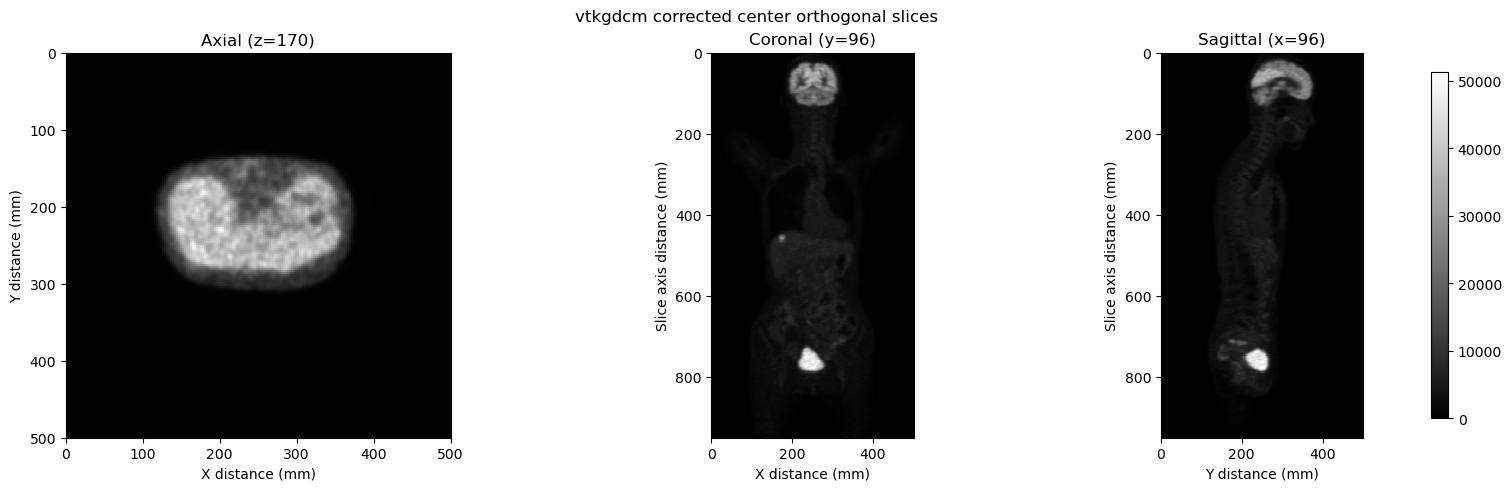

In [7]:
vtkgdcm_corrected_display_spacing = _image_position_orientation_derived_display_spacing(
    INPUT_PATH,
    vtkgdcm_volume_image,
)
if vtkgdcm_corrected_display_spacing is None:
    print('Image-position-derived spacing correction is available for directory series with usable image position and image orientation metadata only.')
else:
    _show_center_orthogonal_slices(
        vtkgdcm_volume_image,
        vtkgdcm_volume_array,
        "vtkgdcm corrected",
        spacing_override=vtkgdcm_corrected_display_spacing,
    )


## `dicomsdl.vtk_bridge.read_series_image_data`

This bridge returns `vtkImageData` while canonicalizing 3D stacks into
physical slice order with positive slice spacing.


In [8]:
dicomsdl_image = _read_with_dicomsdl(INPUT_PATH)
dicomsdl_array = _print_vtk_summary(
    "dicomsdl.vtk_bridge.read_series_image_data",
    dicomsdl_image,
)

dicomsdl.vtk_bridge.read_series_image_data
  dims: (192, 192, 341)
  spacing: (2.6041667461395, 2.6041667461395, 2.789999999999992)
  origin: (-248.698, -248.698, -938.6)
  direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
  shape: (341, 192, 192)
  dtype: float32
  range: (np.float32(0.0), np.float32(54127.48))


## Center orthogonal slices from `dicomsdl`

This uses the canonical `dicomsdl.vtk_bridge` geometry directly, so no display
spacing override is needed.

Note that the anatomy may not match a casual screen-based expectation of
"up/down" or "left/right". That does not necessarily mean the volume is wrong.
For a human patient, the DICOM patient-based coordinate system defines the
positive axes as right-to-left for *x*, anterior-to-posterior for *y*, and
feet-to-head for *z*.

Depending on the acquisition plane and the viewer convention, a correctly
oriented volume can still look visually flipped compared with a viewer that
applies its own radiology display convention.

Reference:
https://dicom.nema.org/medical/dicom/current/output/chtml/part03/sect_C.7.6.2.html#sect_C.7.6.2.1.1


dicomsdl image spacing: (2.6041667461395, 2.6041667461395, 2.789999999999992)
dicomsdl center indices: z=170, y=96, x=96
dicomsdl axial z=170: shape=(192, 192), display=500.000 x 500.000 mm
dicomsdl coronal y=96: shape=(341, 192), display=500.000 x 951.390 mm
dicomsdl sagittal x=96: shape=(341, 192), display=500.000 x 951.390 mm


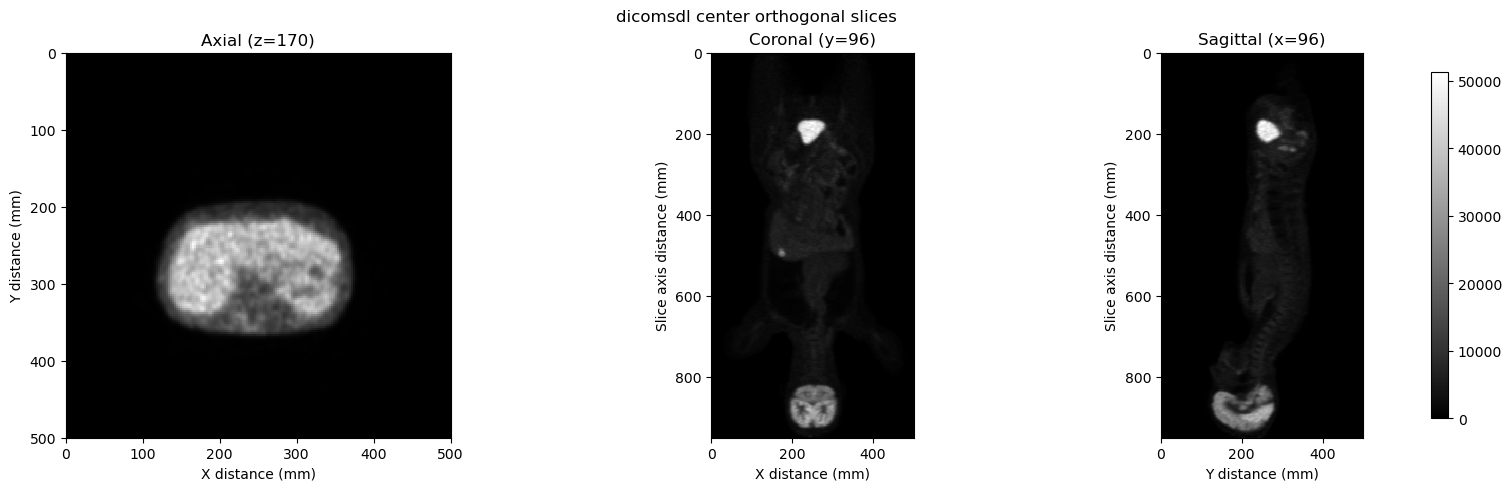

In [9]:
dicomsdl_volume_image = dicomsdl_image
dicomsdl_volume_array = dicomsdl_array

_show_center_orthogonal_slices(
    dicomsdl_volume_image,
    dicomsdl_volume_array,
    "dicomsdl",
)


## Geometry and array-layout comparison

For a regular 3D stack, the three readers may expose different stack order
or in-plane orientation even when the underlying voxel values come from the
same source data.


In [10]:
print("vtk spacing:", tuple(float(v) for v in vtk_image.GetSpacing()))
print("vtkgdcm spacing:", tuple(float(v) for v in vtkgdcm_image.GetSpacing()))
print("dicomsdl spacing:", tuple(float(v) for v in dicomsdl_image.GetSpacing()))
print()
print("vtk origin:", tuple(float(v) for v in vtk_image.GetOrigin()))
print("vtkgdcm origin:", tuple(float(v) for v in vtkgdcm_image.GetOrigin()))
print("dicomsdl origin:", tuple(float(v) for v in dicomsdl_image.GetOrigin()))
print()
print("vtk direction:", _vtk_direction_tuple(vtk_image))
print("vtkgdcm direction:", _vtk_direction_tuple(vtkgdcm_image))
print("dicomsdl direction:", _vtk_direction_tuple(dicomsdl_image))
print()
_compare_arrays("vtk", vtk_array, "dicomsdl", dicomsdl_array)
print()
_compare_arrays("vtkgdcm", vtkgdcm_array, "dicomsdl", dicomsdl_array)


vtk spacing: (2.6041667461395264, 2.6041667461395264, 2.7899999618530273)
vtkgdcm spacing: (2.6041667461395, 2.6041667461395, 1.0)
dicomsdl spacing: (2.6041667461395, 2.6041667461395, 2.789999999999992)

vtk origin: (0.0, 0.0, 0.0)
vtkgdcm origin: (-248.698, 248.69784851264453, 10.0)
dicomsdl origin: (-248.698, -248.698, -938.6)

vtk direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
vtkgdcm direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
dicomsdl direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

vtk shape: (341, 192, 192)
dicomsdl shape: (341, 192, 192)
same shape: True
direct equal: False
flip_y equal: False
flip_zy equal: True

vtkgdcm shape: (341, 192, 192)
dicomsdl shape: (341, 192, 192)
same shape: True
direct equal: False
flip_y equal: False
flip_zy equal: False
